## Import Libraries

We begin by importing the PySTAC library.

In [ ]:
# !pip install pystac
# !pip install erddapy
# !pip install xarray
# !pip install fsspec

import pystac  # STAC client library
from erddapy import ERDDAP  # ERDDAP client library
import xarray as xr # for working with multi-dimensional arrays
import fsspec # for working with remote filesystems (e.g., HTTP, S3)


## Load and explore the PolarWatch STAC Catalog

We load the PolarWatch STAC catalog directly from its online location. Then we can inspect basic information about the catalog such as its ID, description, and links.


In [38]:
# Load the STAC catalog
catalog = pystac.Catalog.from_file("https://shospital.github.io/stac-vue/stac/catalog.json")

# List Collections in the catalog
collections = list(catalog.get_children())

# Print collection IDs
for c in collections:
    print(c.id)

noaacwSARciceclassnpoleDaily
noaacwVIIRSnppiceconcNP06Daily
noaacwVIIRSnppiceconcNP06Daily4Day
noaacwVIIRSnppiceconcSP06Daily
noaacwVIIRSnppiceconcSP06Daily4Day
noaacwVIIRSn20iceconcNP06Daily
noaacwVIIRSn20iceconcNP06Daily4Day
noaacwVIIRSn20iceconcSP06Daily
noaacwVIIRSn20iceconcSP06Daily4Day
noaacwVIIRSnppicesrftempNP06Daily
noaacwVIIRSnppicesrftempNP06Daily4Day
noaacwVIIRSnppicesrftempSP06Daily
noaacwVIIRSnppicesrftempSP06Daily4Day
noaacwVIIRSn20icesrftempNP06Daily
noaacwVIIRSn20icesrftempNP06Daily4Day
noaacwVIIRSn20icesrftempSP06Daily
noaacwVIIRSn20icesrftempSP06Daily4Day
noaacwVIIRSnppicethickNP06Daily
noaacwVIIRSnppicethickNP06Daily4Day
noaacwVIIRSnppicethickSP06Daily
noaacwVIIRSnppicethickSP06Daily4Day
noaacwVIIRSn20icethickNP06Daily
noaacwVIIRSn20icethickNP06Daily4Day
noaacwVIIRSn20icethickSP06Daily
noaacwVIIRSn20icethickSP06Daily4Day
noaacwSARnrcsnpoleDaily
lara_snowdepth_5yrs_awi_nh
lara_snowdepth_5yrs_esa_nh


## List collections with ERDDAP service

In [ ]:
# List collections with ERDDAP service

for coll in catalog.get_children():
    if coll.extra_fields.get("pw:service_type") == "erddap":
        print(coll.id, coll.assets["files"].href)

noaacwSARciceclassnpoleDaily https://coastwatch.noaa.gov/erddap/files/noaacwSARciceclassnpoleDaily
noaacwVIIRSnppiceconcNP06Daily https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSnppiceconcNP06Daily
noaacwVIIRSnppiceconcNP06Daily4Day https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSnppiceconcNP06Daily4Day
noaacwVIIRSnppiceconcSP06Daily https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSnppiceconcSP06Daily
noaacwVIIRSnppiceconcSP06Daily4Day https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSnppiceconcSP06Daily4Day
noaacwVIIRSn20iceconcNP06Daily https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSn20iceconcNP06Daily
noaacwVIIRSn20iceconcNP06Daily4Day https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSn20iceconcNP06Daily4Day
noaacwVIIRSn20iceconcSP06Daily https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSn20iceconcSP06Daily
noaacwVIIRSn20iceconcSP06Daily4Day https://coastwatch.noaa.gov/erddap/files/noaacwVIIRSn20iceconcSP06Daily4Day
noaacwVIIRSnppicesrftempNP06Daily https://coa

## Explore data from ERDDAP

In [ ]:
# Access a specific collection by ID
coll = catalog.get_child("noaacwVIIRSn20iceconcNP06Daily")

# 
service_url = next(l.href for l in coll.links if l.rel == "service")
server, dataset_id = service_url.rsplit("/griddap/", 1)

e = ERDDAP(server=server, protocol="griddap")
e.dataset_id = dataset_id

# Initialize first — this fetches the dataset dimensions
e.griddap_initialize()

# Then set constraints
e.constraints["time>="] = "2024-12-22"
e.constraints["time<="] = "2024-12-22"

# Variables from STAC
e.variables = list(coll.extra_fields.get("item_assets", {}).keys())


ds = e.to_xarray()
print(ds)

<xarray.Dataset> Size: 299MB
Dimensions:   (time: 1, altitude: 1, rows: 8640, cols: 8640)
Coordinates:
  * time      (time) datetime64[ns] 8B 2024-12-21T11:58:29.000499968
  * altitude  (altitude) float64 8B 0.0
  * rows      (rows) float64 69kB 3.434e+06 3.433e+06 ... -3.433e+06 -3.434e+06
  * cols      (cols) float64 69kB -3.434e+06 -3.433e+06 ... 3.433e+06 3.434e+06
Data variables:
    IceConc   (time, altitude, rows, cols) float32 299MB ...
Attributes: (12/36)
    cdm_data_type:                     Grid
    Conventions:                       CF-1.6, COARDS, ACDD-1.3
    creator_email:                     coastwatch.info@noaa.gov
    creator_name:                      NOAA/NESDIS/STAR/SOCD/CoastWatch
    creator_url:                       https://coastwatch.noaa.gov
    crs_wkt:                           PROJCS["WGS 84 / NSIDC Sea Ice Polar S...
    ...                                ...
    start_orbit_number:                43126
    summary:                           Enterprise I

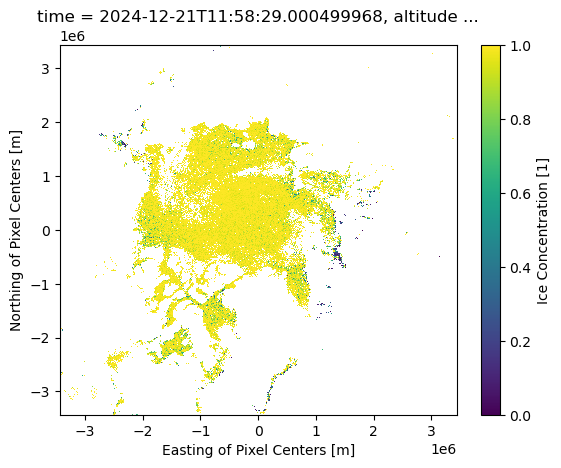

In [ ]:
# Visualize the data
ds['IceConc'].plot()

## List data from HTTPS

In [41]:
for coll in catalog.get_children():
    if coll.extra_fields.get("pw:service_type") == "https":
        files = coll.assets["files"].href
        print(f"{coll.id}: {files}")
        for item in coll.get_items():
            print(f"  {item.id}: {item.assets['data'].href}")


       

lara_snowdepth_5yrs_awi_nh: https://www.star.nesdis.noaa.gov/data/pub0052/polarwatch/erddap/lara_snowdepth_5yrs_awi_nh/
  lara_snowdepth_5yrs_awi_nh_20180112: https://www.star.nesdis.noaa.gov/data/pub0052/polarwatch/erddap/lara_snowdepth_5yrs_awi_nh/LaRa_5yr_I2_AWI_E_ssmigrid_01.nc
  lara_snowdepth_5yrs_awi_nh_20180212: https://www.star.nesdis.noaa.gov/data/pub0052/polarwatch/erddap/lara_snowdepth_5yrs_awi_nh/LaRa_5yr_I2_AWI_E_ssmigrid_02.nc
  lara_snowdepth_5yrs_awi_nh_20180312: https://www.star.nesdis.noaa.gov/data/pub0052/polarwatch/erddap/lara_snowdepth_5yrs_awi_nh/LaRa_5yr_I2_AWI_E_ssmigrid_03.nc
  lara_snowdepth_5yrs_awi_nh_20180412: https://www.star.nesdis.noaa.gov/data/pub0052/polarwatch/erddap/lara_snowdepth_5yrs_awi_nh/LaRa_5yr_I2_AWI_E_ssmigrid_04.nc
  lara_snowdepth_5yrs_awi_nh_20181112: https://www.star.nesdis.noaa.gov/data/pub0052/polarwatch/erddap/lara_snowdepth_5yrs_awi_nh/LaRa_5yr_I2_AWI_E_ssmigrid_11.nc
  lara_snowdepth_5yrs_awi_nh_20181212: https://www.star.nesdis.no

## Explore data from HTTPS

In [42]:
coll = catalog.get_child("lara_snowdepth_5yrs_awi_nh")
items = list(coll.get_items())


urls = [item.assets["data"].href for item in items[:2]]
files = [fsspec.open(url).open() for url in urls]
ds = xr.open_mfdataset(files, engine="h5netcdf")
print(ds)

<xarray.Dataset> Size: 7MB
Dimensions:       (time: 2, y: 448, x: 304)
Coordinates:
    xgrid         (x) float32 1kB dask.array<chunksize=(304,), meta=np.ndarray>
    ygrid         (y) float32 2kB dask.array<chunksize=(448,), meta=np.ndarray>
  * time          (time) datetime64[ns] 16B 2018-01-12 2018-02-12
Dimensions without coordinates: y, x
Data variables:
    grid_lat      (time, y, x) float64 2MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    grid_lon      (time, y, x) float64 2MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    LaRA_sd_5yr   (time, y, x) float64 2MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cdr_variable  (time) <U11 88B 'LaRA_sd_5yr' 'LaRA_sd_5yr'
    projection    (time) int32 8B 1 1
Attributes: (12/34)
    Conventions:               CF-1.6, ACDD-1.3
    institution:               NOAA > NESDIS > Center for Satellite Applicati...
    program:                   NOAA/Laboratory for Satellite Altimetry
    cdr_variable:            

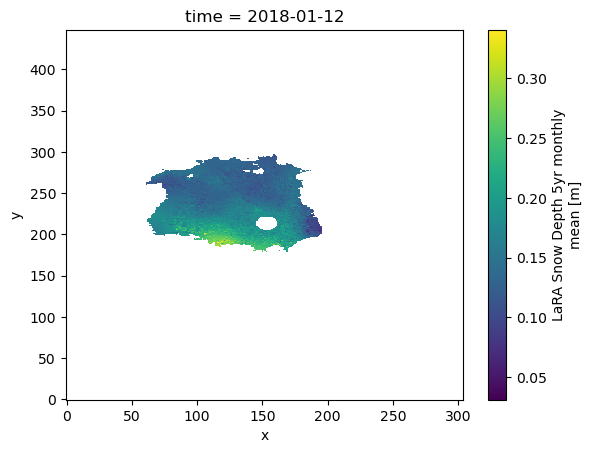

In [ ]:
# Visualize the first time step data
ds['LaRA_sd_5yr'][0].plot()